# Qwen2.5-1.5B Fine-Tuning
### Fine-tuning `unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit`

## 1. Install Dependencies

In [2]:
!pip install torch transformers datasets accelerate peft bitsandbytes \
            huggingface_hub evaluate safetensors sentence-transformers \
            unsloth_zoo sacrebleu rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.7/842.7 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 22.5 MB/s eta 0:00:00


In [1]:
!pip install git+https://github.com/unslothai/unsloth.git

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-req-build-gd0c_evf
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-req-build-gd0c_evf
  Resolved https://github.com/unslothai/unsloth.git to commit b01a1ba1c2d8840051309290abee8ca97cdd6431
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unsloth: filename=unsloth-2026.5.4-py3-none-any.whl size=34314679 sha256=da175edad16984302e28533741be22699894dd8d7e515fa3ea8e2236e6bdd915
  Stored in directory: /tmp/pip-ephem-wheel-cache-69e6mk4k/wheels/60/3e/1f/e576c07051d90cf64b6a41434d87ccf4db33fafd5343bf5de0
Successfully built unsloth


## 2. Import Libraries

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset, concatenate_datasets
from unsloth import FastLanguageModel, is_bfloat16_supported

from trl import SFTTrainer, SFTConfig
from trl import DPOTrainer, DPOConfig

from evaluate import load
from sacrebleu import BLEU
from rouge_score import rouge_scorer

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## 3. Load Base Model & Tokenizer

In [3]:
max_seq_length = 2048
dtype          = None
load_in_4bit   = True
Base_Model     = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=Base_Model,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": tokenizer.eos_token})

==((====))==  Unsloth 2026.5.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


## 4. Apply LoRA Adapters

In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.4 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


## 5. Load & Split Dataset

In [5]:
fiqa = load_dataset("LLukas22/fiqa")
alpaca = load_dataset("gbharti/finance-alpaca")

README.md: 0.00B [00:00, ?B/s]

train.json:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14511 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2561 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/831 [00:00<?, ?B/s]

Cleaned_date.json:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68912 [00:00<?, ? examples/s]

In [6]:
def normalize_fiqa(example):
    return {
        "question": example["question"],
        "answer": example["answer"]
    }

def normalize_alpaca(example):
    return {
        "question": example["instruction"],
        "answer": example["output"]
    }

In [7]:
fiqa_train = fiqa["train"].map(normalize_fiqa)
alpaca_train = alpaca["train"].map(normalize_alpaca)

Map:   0%|          | 0/14511 [00:00<?, ? examples/s]

Map:   0%|          | 0/68912 [00:00<?, ? examples/s]

In [8]:
merged_dataset = concatenate_datasets([
    fiqa_train,
    alpaca_train,
]).shuffle(seed=42)

In [9]:
split = merged_dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = split["train"]
temp_dataset = split["test"]

eval_split = temp_dataset.train_test_split(test_size=0.5, seed=42)

eval_dataset = eval_split["train"]
test_dataset = eval_split["test"]


print(f"Train dataset size: {len(train_dataset)}")
print(f"Eval dataset size: {len(eval_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 75080
Eval dataset size: 4171
Test dataset size: 4172


In [10]:
train_dataset[995]

{'question': 'Why would a central bank or country not want their currency to appreciate against other currencies?',
 'answer': 'It would essentially make goods from other countries more cheaper than goods from US. And it would make imports from these countries to China more expensive.  The below illustration is just with 2 major currencies and is more illustrative to show the effect. It does not actually mean the goods from these countries would be cheaper. 1 GBP = 1.60 USD  1 EUR = 1.40 USD 1 CNY = 0.15 USD Lets say the above are the rates for GBP, EUR, CNY. The cost of a particular goods (assume Pencils) in international market is 2 USD. This means for the cost of manufacturing this should be less than GBP 1.25 in UK, less than 1.43 in Euro Countires, less than 13.33 CNY in China. Only then export would make sense. If the real cost of manufacturing is say 1.4 GBP in UK, 1.5 EUR in Euro countires, clearly they cannot compete and would loose. Now lets say the USD has appreciated by 20%

## 7. Apply Chat Template to Train & Eval Datasets

In [11]:
custom_system_message = (
    "You are a financial intelligence assistant"
    "Provide accurate, structured financial explanations."
)

def format_chat(example):
    messages = [
        {"role": "system", "content": custom_system_message},
        {"role": "user", "content": example["question"]},
        {"role": "assistant", "content": example["answer"]},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    return {"text": text}


train_dataset = train_dataset.map(format_chat)
eval_dataset = eval_dataset.map(format_chat)
test_dataset = test_dataset.map(format_chat)

Map:   0%|          | 0/75080 [00:00<?, ? examples/s]

Map:   0%|          | 0/4171 [00:00<?, ? examples/s]

Map:   0%|          | 0/4172 [00:00<?, ? examples/s]

In [13]:
train_dataset[995]['text']

'<|im_start|>system\nYou are a financial intelligence assistantProvide accurate, structured financial explanations.<|im_end|>\n<|im_start|>user\nWhy would a central bank or country not want their currency to appreciate against other currencies?<|im_end|>\n<|im_start|>assistant\nIt would essentially make goods from other countries more cheaper than goods from US. And it would make imports from these countries to China more expensive.  The below illustration is just with 2 major currencies and is more illustrative to show the effect. It does not actually mean the goods from these countries would be cheaper. 1 GBP = 1.60 USD  1 EUR = 1.40 USD 1 CNY = 0.15 USD Lets say the above are the rates for GBP, EUR, CNY. The cost of a particular goods (assume Pencils) in international market is 2 USD. This means for the cost of manufacturing this should be less than GBP 1.25 in UK, less than 1.43 in Euro Countires, less than 13.33 CNY in China. Only then export would make sense. If the real cost of 

## 8. Configure SFTTrainer & Training Arguments

In [14]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    tokenizer=tokenizer,
    args=SFTConfig(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        warmup_steps=20,
        max_steps=400,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        eval_steps=50,
        save_steps=100,
        output_dir="outputs",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/75080 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4171 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


## 9. Train the Model

In [15]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 75,080 | Num Epochs = 1 | Total steps = 400
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 36,929,536 of 1,580,643,840 (2.34% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,2.706355
20,1.838779
30,1.867870
40,2.035277
50,1.969270
60,1.872686
70,2.075605
80,1.785248
90,2.100350
100,1.754046


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-400/tokenizer_config.json.


## 10. Save LoRA Adapter

In [16]:
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")

Unsloth: Restored added_tokens_decoder metadata in lora_model/tokenizer_config.json.


('lora_model/tokenizer_config.json',
 'lora_model/chat_template.jinja',
 'lora_model/tokenizer.json')

## 11. Evaluation
### Comparing Base Model vs Fine-Tuned Model using Perplexity, BLEU, and ROUGE

We evaluate on `test_dataset` (raw, unformatted) which the model has never seen during training.

In [17]:
# Base model
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=Base_Model,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

FastLanguageModel.for_inference(base_model)

# Fine-tuned model
ft_model, _ = FastLanguageModel.from_pretrained(
    model_name="lora_model",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

FastLanguageModel.for_inference(ft_model)

==((====))==  Unsloth 2026.5.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
==((====))==  Unsloth 2026.5.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536, padding_idx=151665)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
        

# Prepare evaluation data

In [18]:
N_EVAL = 50

test_raw = test_dataset.select(range(N_EVAL))

prompts = []
references = []
ppl_texts = []

for example in test_raw:

    # The 'instruction' field contains the user's prompt content
    instruction_content = example["question"]
    # The 'output' field contains the assistant's reference answer
    reference_answer = example["answer"]
    # The 'text' field contains the full chat formatted for perplexity calculation
    full_text_for_perplexity = example["text"]

    # Construct the prompt for generation: only the user's instruction, formatted with add_generation_prompt=True
    prompt_messages_for_generation = [
        {"role": "system", "content": custom_system_message},
        {"role": "user", "content": instruction_content}
    ]
    prompt = tokenizer.apply_chat_template(
        prompt_messages_for_generation,
        tokenize=False,
        add_generation_prompt=True
    )

    prompts.append(prompt)
    references.append(reference_answer)
    ppl_texts.append(full_text_for_perplexity)

print(f"Prepared {len(prompts)} evaluation samples.")

print("\n── Sample Prompt ──\n")
print(prompts[0][:1000])

print("\n── Sample Reference ──\n")
print(references[0][:500])

Prepared 50 evaluation samples.

── Sample Prompt ──

<|im_start|>system
You are a financial intelligence assistantProvide accurate, structured financial explanations.<|im_end|>
<|im_start|>user
Relation between interest rates and currency for a nation<|im_end|>
<|im_start|>assistant


── Sample Reference ──

From Indian context, there are a number of factors that are influencing the economic condition and the exchange rate, interest rate etc. are reflection of the situation. I shall try and answer the question through the above Indian example. India is running a budget deficit of 4 odd % for last 6-7 years, which means that gov.in is spending more than their revenue collection, this money is not in the system, so the govt. has to print the money, either the direct 4% or the interest it has to pay on


### 12. Perplexity

In [19]:
def compute_perplexity(model, tokenizer, texts, max_len=2048):

    model.eval()

    losses = []

    with torch.no_grad():

        for text in texts:

            enc = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=max_len
            ).to(model.device)

            outputs = model(
                **enc,
                labels=enc["input_ids"]
            )

            losses.append(outputs.loss.item())

    ppl = np.exp(np.mean(losses))

    return round(float(ppl), 2)


base_ppl = compute_perplexity(
    base_model,
    tokenizer,
    ppl_texts
)

ft_ppl = compute_perplexity(
    ft_model,
    tokenizer,
    ppl_texts
)

print(f"Base model PPL : {base_ppl}")
print(f"Fine-tuned PPL : {ft_ppl}")

print(
    f"Improvement : "
    f"{round((base_ppl - ft_ppl) / base_ppl * 100, 1)}%"
)

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

Base model PPL : 28.07
Fine-tuned PPL : 5.81
Improvement : 79.3%


### 13. BLEU & ROUGE

In [20]:
def generate(model, tokenizer, prompt, max_new=128):

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    prediction = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

    return prediction.strip()

print("Generating base model predictions...")
base_preds = [
    generate(base_model, tokenizer, p)
    for p in prompts
]

print("Generating fine-tuned model predictions...")
ft_preds = [
    generate(ft_model, tokenizer, p)
    for p in prompts
]

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating base model predictions...


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Generating fine-tuned model predictions...


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

In [21]:
bleu = BLEU()

base_bleu = bleu.corpus_score(
    base_preds,
    [references]
).score

ft_bleu = bleu.corpus_score(
    ft_preds,
    [references]
).score

print(f"\nBLEU base={base_bleu:.2f}")
print(f"BLEU fine-tuned={ft_bleu:.2f}")


BLEU base=2.36
BLEU fine-tuned=3.82


In [22]:
rouge = rouge_scorer.RougeScorer(
    ["rouge1", "rougeL"],
    use_stemmer=True
)

def avg_rouge(preds, refs):

    r1_scores = []
    rL_scores = []

    for pred, ref in zip(preds, refs):

        scores = rouge.score(ref, pred)

        r1_scores.append(
            scores["rouge1"].fmeasure
        )

        rL_scores.append(
            scores["rougeL"].fmeasure
        )

    return (
        round(sum(r1_scores) / len(r1_scores), 4),
        round(sum(rL_scores) / len(rL_scores), 4),
    )

base_r1, base_rL = avg_rouge(
    base_preds,
    references
)

ft_r1, ft_rL = avg_rouge(
    ft_preds,
    references
)

print(f"ROUGE-1 base={base_r1}")
print(f"ROUGE-1 fine-tuned={ft_r1}")

print(f"ROUGE-L base={base_rL}")
print(f"ROUGE-L fine-tuned={ft_rL}")

ROUGE-1 base=0.2596
ROUGE-1 fine-tuned=0.3069
ROUGE-L base=0.1439
ROUGE-L fine-tuned=0.1805


# Final Summary Table

In [23]:
print("\n" + "─" * 60)

print(
    f"{'Metric':<15}"
    f"{'Base':>12}"
    f"{'Fine-tuned':>15}"
    f"{'Result':>15}"
)

print("─" * 60)

metrics = [
    ("PPL ↓", base_ppl, ft_ppl, True),
    ("BLEU ↑", base_bleu, ft_bleu, False),
    ("ROUGE-1 ↑", base_r1, ft_r1, False),
    ("ROUGE-L ↑", base_rL, ft_rL, False),
]

for metric, base_v, ft_v, lower_better in metrics:

    improved = (
        ft_v < base_v
        if lower_better
        else ft_v > base_v
    )

    result = (
        "✓ improved"
        if improved
        else "✗ regressed"
    )

    print(
        f"{metric:<15}"
        f"{base_v:>12.4f}"
        f"{ft_v:>15.4f}"
        f"{result:>15}"
    )

print("─" * 60)


────────────────────────────────────────────────────────────
Metric                 Base     Fine-tuned         Result
────────────────────────────────────────────────────────────
PPL ↓               28.0700         5.8100     ✓ improved
BLEU ↑               2.3573         3.8204     ✓ improved
ROUGE-1 ↑            0.2596         0.3069     ✓ improved
ROUGE-L ↑            0.1439         0.1805     ✓ improved
────────────────────────────────────────────────────────────


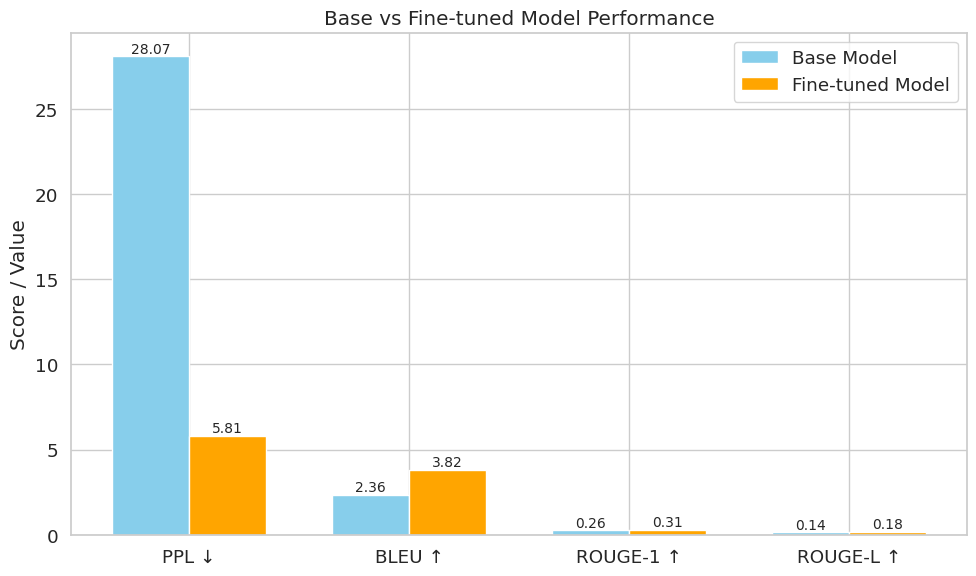

In [24]:
# Metrics data
metrics = ["PPL ↓", "BLEU ↑", "ROUGE-1 ↑", "ROUGE-L ↑"]
base_values = [base_ppl, base_bleu, base_r1, base_rL]
finetuned_values = [ft_ppl, ft_bleu, ft_r1, ft_rL]

# Plot style
sns.set(style="whitegrid", font_scale=1.2)

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar([i - width/2 for i in x], base_values, width, label="Base Model", color="skyblue")
plt.bar([i + width/2 for i in x], finetuned_values, width, label="Fine-tuned Model", color="orange")

# Labels and formatting
plt.xticks(x, metrics)
plt.ylabel("Score / Value")
plt.title("Base vs Fine-tuned Model Performance")
plt.legend()

# Annotate improvements
for i, (b, f) in enumerate(zip(base_values, finetuned_values)):
    plt.text(i - width/2, b + 0.01, f"{b:.2f}", ha="center", va="bottom", fontsize=10)
    plt.text(i + width/2, f + 0.01, f"{f:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

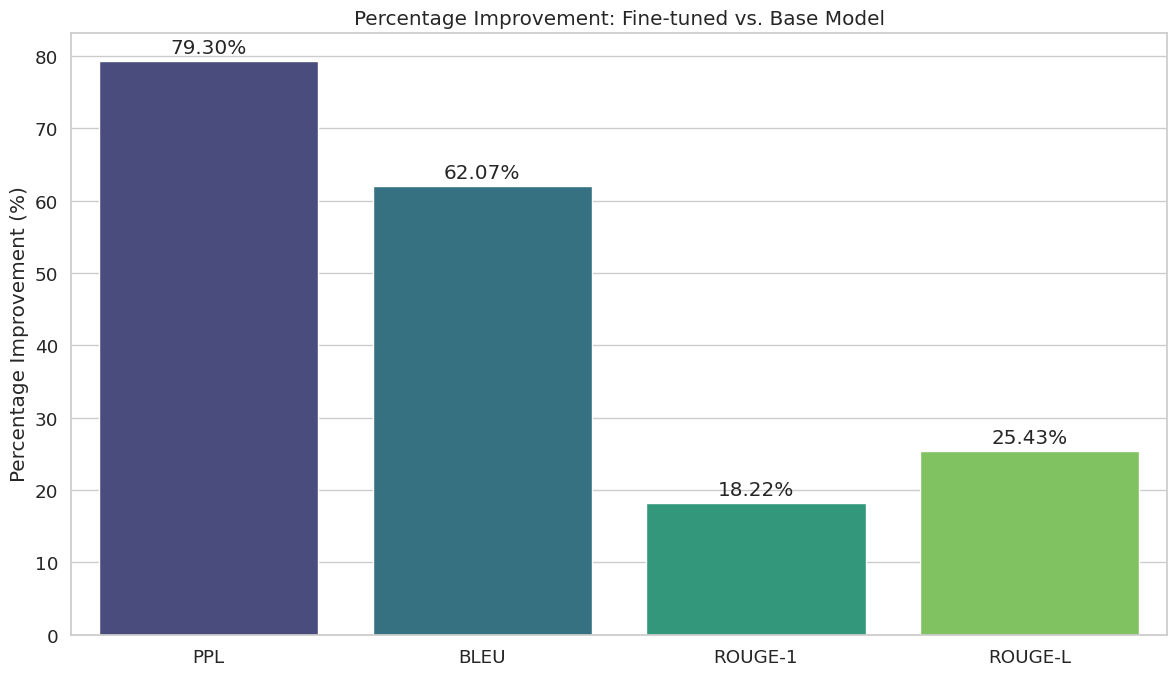

In [25]:
metric_labels = [
    "PPL",
    "BLEU",
    "ROUGE-1",
    "ROUGE-L"
]

# Using the variables computed in previous cells for consistency
plot_data = [
    ("PPL", base_ppl, ft_ppl, True),
    ("BLEU", base_bleu, ft_bleu, False),
    ("ROUGE-1", base_r1, ft_r1, False),
    ("ROUGE-L", base_rL, ft_rL, False)
]

improvement_percentages = []

for name, base_val, ft_val, lower_is_better in plot_data:
    if base_val == 0: # Avoid division by zero, though unlikely for these metrics
        improvement_percentages.append(0.0)
    else:
        if lower_is_better:
            # For metrics where lower is better (e.g., PPL), improvement means base_val is higher than ft_val
            improvement = ((base_val - ft_val) / base_val) * 100
        else:
            # For metrics where higher is better, improvement means ft_val is higher than base_val
            improvement = ((ft_val - base_val) / base_val) * 100
        improvement_percentages.append(improvement)


plt.figure(figsize=(12, 7))
sns.barplot(x=metric_labels, y=improvement_percentages, hue=metric_labels, palette="viridis", legend=False)

plt.ylabel("Percentage Improvement (%)")
plt.title("Percentage Improvement: Fine-tuned vs. Base Model")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line for reference

# Annotate bars with their percentage values
for index, value in enumerate(improvement_percentages):
    plt.text(
        index,
        value + (1 if value >= 0 else -1) * 0.5, # Adjust text position slightly above/below bar
        f'{value:.2f}%',
        ha='center',
        va='bottom' if value >= 0 else 'top'
    )

plt.tight_layout()
plt.show()

### Compare Base vs Fine-Tuned Model for a specific question

In [49]:
question = "Why can a profitable company still go bankrupt?"

# Prepare the prompt for the base model
base_prompt_messages = [
    {"role": "user", "content": question}
]
base_prompt = tokenizer.apply_chat_template(
    base_prompt_messages,
    tokenize=False,
    add_generation_prompt=True
)

# Prepare the prompt for the fine-tuned model (including custom system message)
ft_prompt_messages = [
    {"role": "user", "content": question}
]
ft_prompt = tokenizer.apply_chat_template(
    ft_prompt_messages,
    tokenize=False,
    add_generation_prompt=True
)

print("Generating base model response...")
base_model_response = generate(base_model, tokenizer, base_prompt)

print("Generating fine-tuned model response...")
ft_model_response = generate(ft_model, tokenizer, ft_prompt)

print("\n--- Question ---\n")
print(question)

print("\n--- Base Model Response ---\n")
print(base_model_response)

print("\n--- Fine-tuned Model Response ---\n")
print(ft_model_response)


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating base model response...


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating fine-tuned model response...

--- Question ---

Why can a profitable company still go bankrupt?

--- Base Model Response ---

A profitable company can still go bankrupt for several reasons:

1. **Financial Overextension**: Even if the company is financially healthy and generating profits, it might be overextending itself in terms of debt or investments that cannot be supported.

2. **Market Conditions**: The market conditions can change rapidly, leading to unexpected losses or increased costs that exceed the company's ability to recover.

3. **Operational Issues**: Internal issues such as supply chain disruptions, production inefficiencies, or poor management decisions can lead to financial difficulties.

4. **Regulatory Changes**: Regulatory changes or compliance issues can significantly impact a company’s operations and profitability.

5

--- Fine-tuned Model Response ---

A company is not just a collection of assets and liabilities; it's also a business entity with its ow

## 14. Convert Model to gguf

In [50]:
MERGED_DIR = "/content/qwen2.5-finance-assistant-merged"

model.save_pretrained_merged(
    MERGED_DIR,
    tokenizer,
    save_method="merged_16bit"
)

print("Merged 16-bit model saved.")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/qwen2.5-finance-assistant-merged/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [01:03<00:00, 63.13s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:40<00:00, 100.77s/it]


Unsloth: Merge process complete. Saved to `/content/qwen2.5-finance-assistant-merged`
Merged 16-bit model saved.


In [51]:
!rm -rf /content/llama.cpp

!git clone https://github.com/ggerganov/llama.cpp
%cd /content/llama.cpp

!apt-get update -qq
!apt-get install -y cmake build-essential

!cmake -B build
!cmake --build build --config Release -j4

Cloning into 'llama.cpp'...
remote: Enumerating objects: 94654, done.
remote: Counting objects: 100% (297/297), done.
remote: Compressing objects: 100% (187/187), done.
remote: Total 94654 (delta 175), reused 120 (delta 110), pack-reused 94357 (from 2)
Receiving objects: 100% (94654/94654), 393.48 MiB | 24.46 MiB/s, done.
Resolving deltas: 100% (67280/67280), done.
Updating files: 100% (2856/2856), done.
/content/llama.cpp
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- 

In [52]:
!python /content/llama.cpp/convert_hf_to_gguf.py \
    /content/qwen2.5-finance-assistant-merged \
    --outfile /content/qwen2.5-finance-assistant-f16.gguf \
    --outtype f16

INFO:hf-to-gguf:Loading model: qwen2.5-finance-assistant-merged
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:hf-to-gguf:Model architecture: Qwen2ForCausalLM
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors'
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:token_embd.weight,         torch.bfloat16 --> F16, shape = {1536, 151936}
INFO:hf-to-gguf:blk.0.attn_norm.weight,    torch.bfloat16 --> F32, shape = {1536}
INFO:hf-to-gguf:blk.0.ffn_down.weight,     torch.bfloat16 --> F16, shape = {8960, 1536}
INFO:hf-to-gguf:blk.0.ffn_gate.weight,     torch.bfloat16 --> F16, shape = {1536, 8960}
INFO:hf-to-gguf:blk.0.ffn_up.weight,       torch.bfloat16 --> F16, shape = {1536, 8960}
INFO:hf-to-gguf:blk.0.ffn_norm.weight,     torch.bfloat16 --> F32, shape = {1536}
INFO:hf-to-gguf:blk.0.attn_k.bias,         torch.bfloat16 --> F32, shape = {256}
INFO:hf-to-gguf:blk.0.attn_k.weight,       torch.bfloat16 --> F16,

In [53]:
!/content/llama.cpp/build/bin/llama-quantize \
    /content/qwen2.5-finance-assistant-f16.gguf \
    /content/qwen2.5-finance-assistant-q4_k_m.gguf \
    q4_k_m

llama_print_build_info: build = 9235 (d14ce3dab)
llama_print_build_info: built with GNU 11.4.0 for Linux x86_64
main: quantizing '/content/qwen2.5-finance-assistant-f16.gguf' to '/content/qwen2.5-finance-assistant-q4_k_m.gguf' as Q4_K_M
llama_model_loader: loaded meta data with 25 key-value pairs and 338 tensors from /content/qwen2.5-finance-assistant-f16.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen2
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                     general.sampling.top_k i32              = 20
llama_model_loader: - kv   3:                     general.sampling.top_p f32              = 0.800000
llama_model_loader: - kv   4:                      general.sampling.temp f32              = 0.700000
llama_model_loader:

## 15. Push to Hugging Face Hub

In [54]:
from huggingface_hub import HfApi, logout, notebook_login

notebook_login()

api = HfApi()

In [55]:
repo_id = "junaid17/qwen2.5-finance-assistant-gguf"

# Create the repository, if it doesn't exist already
api.create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True
)

# Upload the GGUF file
api.upload_file(
    path_or_fileobj="/content/qwen2.5-finance-assistant-q4_k_m.gguf",
    path_in_repo="qwen2.5-finance-assistant-q4_k_m.gguf",
    repo_id=repo_id,
    repo_type="model"
)

print("GGUF uploaded successfully.")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nce-assistant-q4_k_m.gguf:   0%|          | 1.10MB /  986MB            

GGUF uploaded successfully.
